# Classification - Default of Credit Card Clients

**Problem statement:** Predict whether a credit card client will default on their payment next month (`default.payment.next.month`) based on demographic attributes, credit data, and payment history.

**Source:** UCI Machine Learning Repository, dataset 350.

## 1. Setup and reproducibility

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
TARGET = "default"
FEATURES = None 

np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="colorblind")

## 2. Dataset loading and audit

In [2]:
data_path = Path("data/classification.csv")

if not data_path.exists():
    data_path = Path("../data/classification.csv")

df = pd.read_csv(data_path)

column_map = {
    "X1": "LIMIT_BAL",
    "X2": "SEX",
    "X3": "EDUCATION",
    "X4": "MARRIAGE",
    "X5": "AGE",
    "X6": "PAY_0",
    "X7": "PAY_2",
    "X8": "PAY_3",
    "X9": "PAY_4",
    "X10": "PAY_5",
    "X11": "PAY_6",
    "X12": "BILL_AMT1",
    "X13": "BILL_AMT2",
    "X14": "BILL_AMT3",
    "X15": "BILL_AMT4",
    "X16": "BILL_AMT5",
    "X17": "BILL_AMT6",
    "X18": "PAY_AMT1",
    "X19": "PAY_AMT2",
    "X20": "PAY_AMT3",
    "X21": "PAY_AMT4",
    "X22": "PAY_AMT5",
    "X23": "PAY_AMT6",
    "Y": "default",
}

df.rename(
    columns=column_map,
    inplace=True
)

assert TARGET in df.columns, f"'{TARGET}' not found. Columns: {df.columns.tolist()}"

FEATURES = [
    c for c in df.columns if c not in (
        "ID",
        TARGET
    )
]

print(f"Shape: {df.shape}\n")
display(df.head())

Shape: (30000, 24)



,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
audit = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_count": df.isna().sum(),
        "missing_percent": df.isna().mean().mul(100).round(2),
        "unique_values": df.nunique(),
    }
)

display(audit)

print(f"Duplicate rows: {df.duplicated().sum()}")

,dtype,missing_count,missing_percent,unique_values
LIMIT_BAL,int64,0,0.0,81
SEX,int64,0,0.0,2
EDUCATION,int64,0,0.0,7
MARRIAGE,int64,0,0.0,4
AGE,int64,0,0.0,56
PAY_0,int64,0,0.0,11
PAY_2,int64,0,0.0,11
PAY_3,int64,0,0.0,11
PAY_4,int64,0,0.0,11
PAY_5,int64,0,0.0,10


Duplicate rows: 35


In [4]:
display(df.describe().T)
display(df[TARGET].value_counts(normalize=True).mul(100).round(2).to_frame("target_distribution_%"))

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


,target_distribution_%
default,
0,77.88
1,22.12


### Audit observation

The dataset contains 30,000 observations, 23 predictors, and one binary target, all loading as `int64`/`float64` with no missing values. There are 35 exact duplicate rows that will be removed during cleaning. `EDUCATION` and `MARRIAGE` contain undocumented category codes (0, 5, 6 and 0 respectively) that will need consolidating. The target `default` is imbalanced at 77.9% (0) vs 22.1% (1).

# 3. Exploratory data analysis

## Target distribution

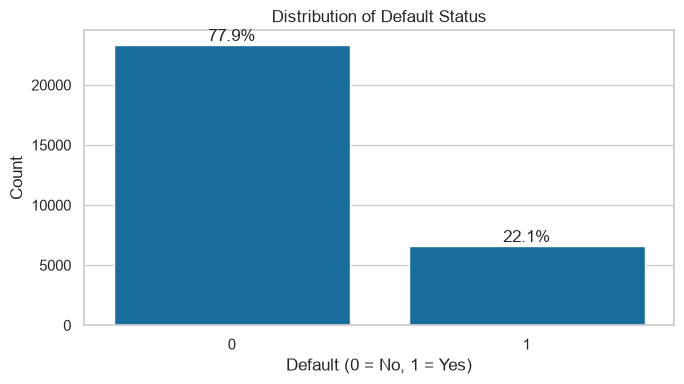

In [5]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(x=TARGET, data=df)
total = len(df)
for p in ax.patches:
    pct = 100 * p.get_height() / total
    ax.annotate(f"{pct:.1f}%", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.title("Distribution of Default Status")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()

**Observation:** The target is imbalanced — roughly 78% of clients did not default (0) versus 22% who did (1). This means accuracy alone would be misleading, so weighted F1, confusion matrices, and a stratified train/test split will be used throughout.

## Feature distribution

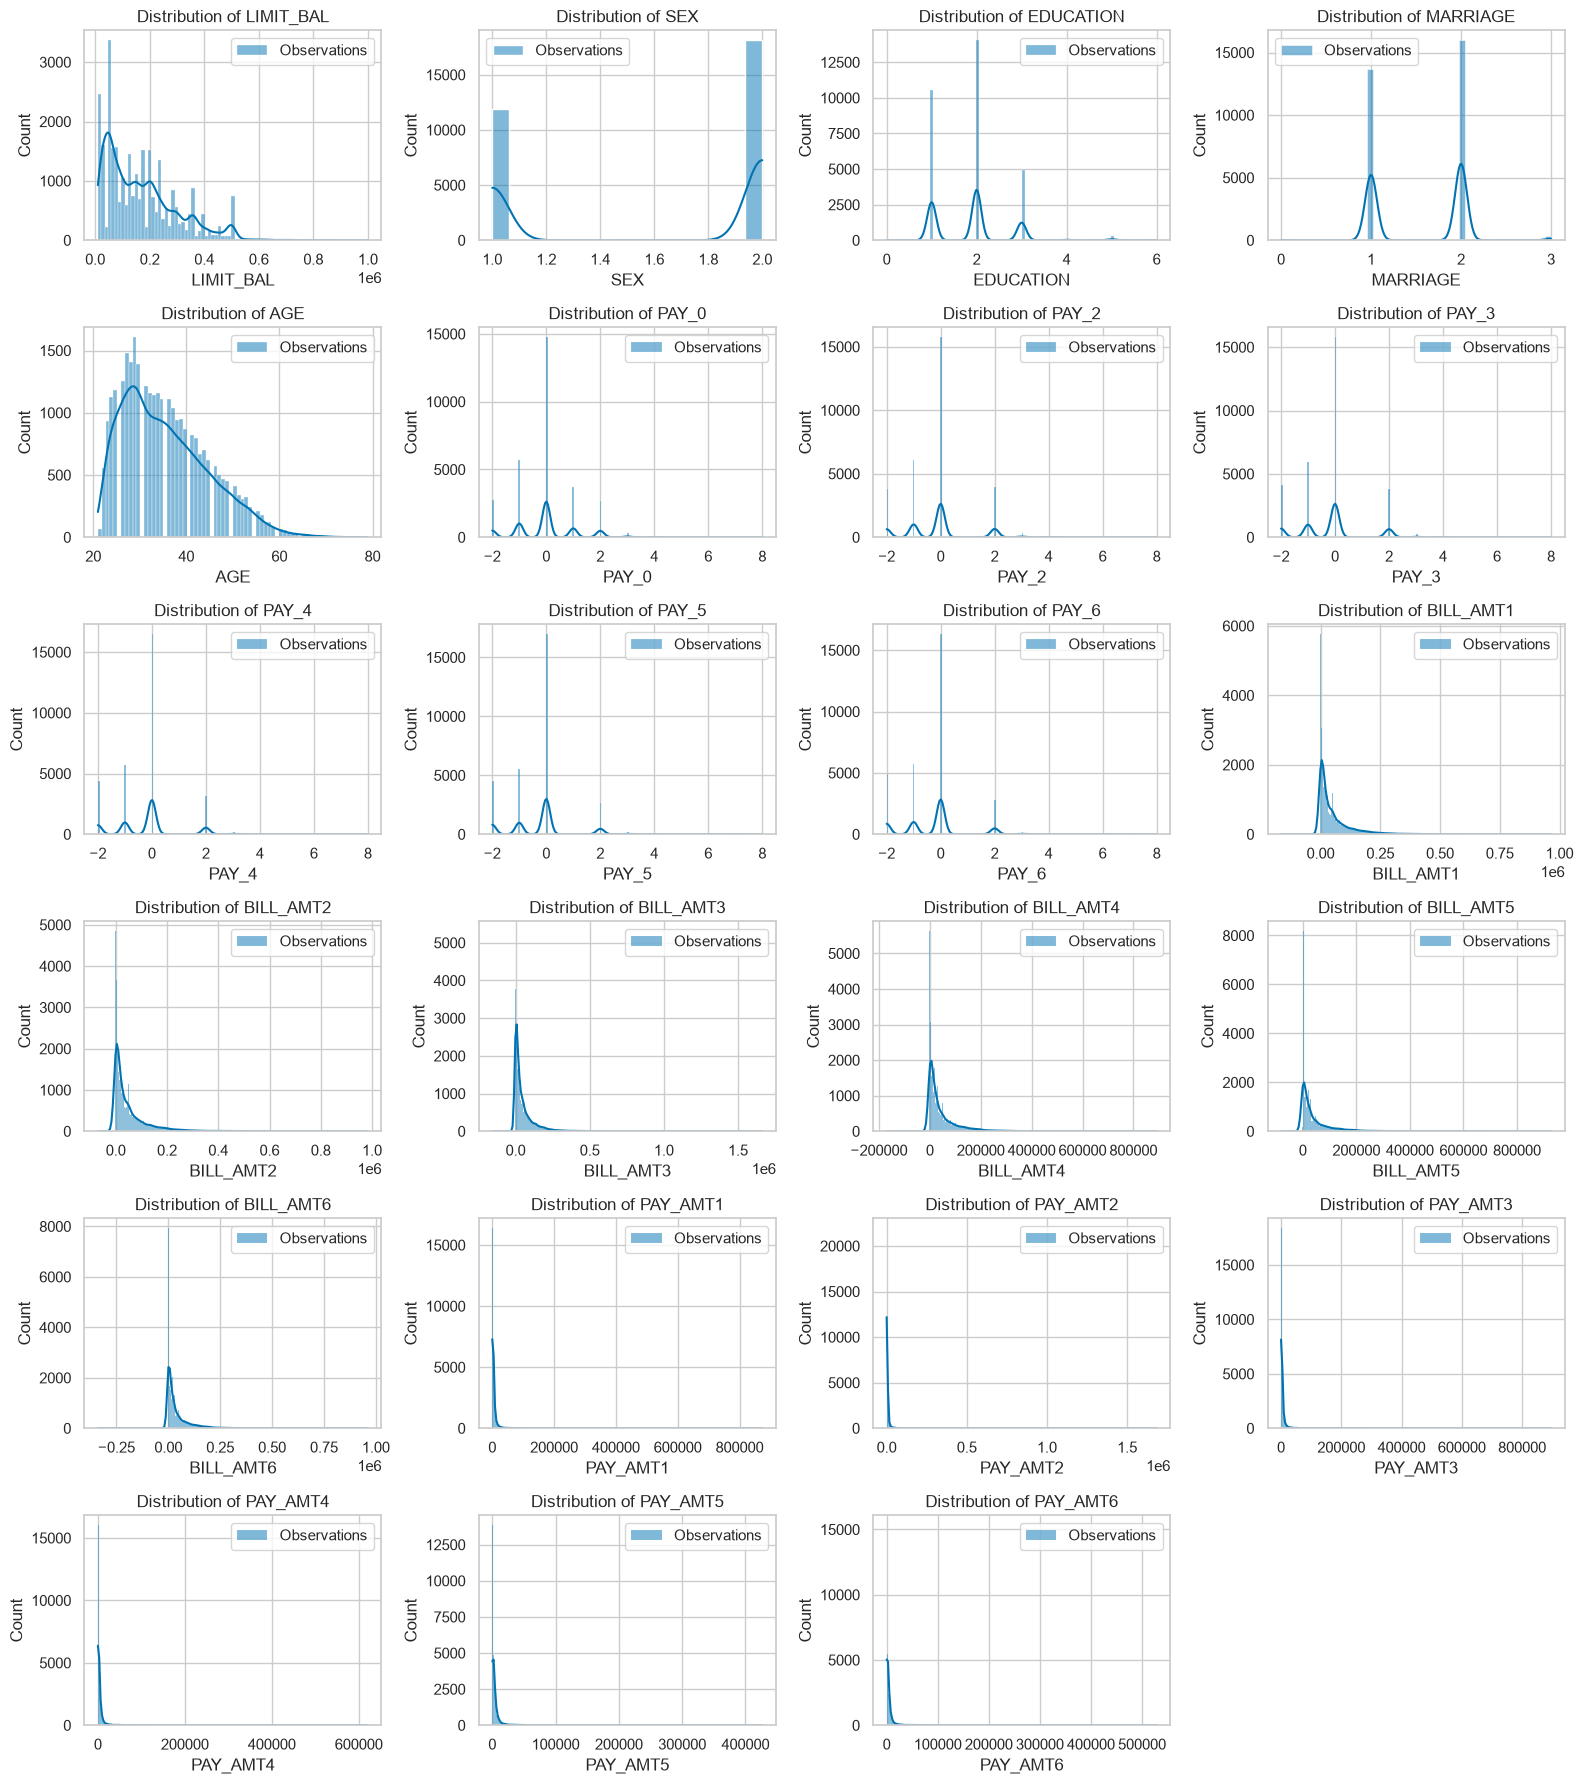

In [6]:
n_cols = 4
n_rows = int(np.ceil(len(FEATURES) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))

for feature, axis in zip(FEATURES, axes.flat):
    sns.histplot(df[feature], kde=True, label="Observations", ax=axis)
    axis.set(title=f"Distribution of {feature}", xlabel=feature, ylabel="Count")
    axis.legend()

for axis in axes.flat[len(FEATURES):]:
    axis.set_visible(False)

plt.tight_layout()

**Observation:** Most monetary columns (`LIMIT_BAL`, `BILL_AMT1`–`BILL_AMT6`, `PAY_AMT1`–`PAY_AMT6`) are heavily right-skewed, with a long tail of high-value clients and a mass near zero; some `BILL_AMT` columns also contain negative values (overpayments/credits). `AGE` is mildly right-skewed, concentrated between 25–45. `SEX`, `EDUCATION`, and `MARRIAGE` are categorical codes rather than continuous distributions, and `EDUCATION`/`MARRIAGE` show unexpected categories (0, 5, 6) beyond their documented range, consistent with the audit findings. `PAY_0`–`PAY_6` cluster heavily around 0 and -1 (on-time/duly-paid), with a smaller spread of positive values indicating payment delay in months.

## Correlation heatmap

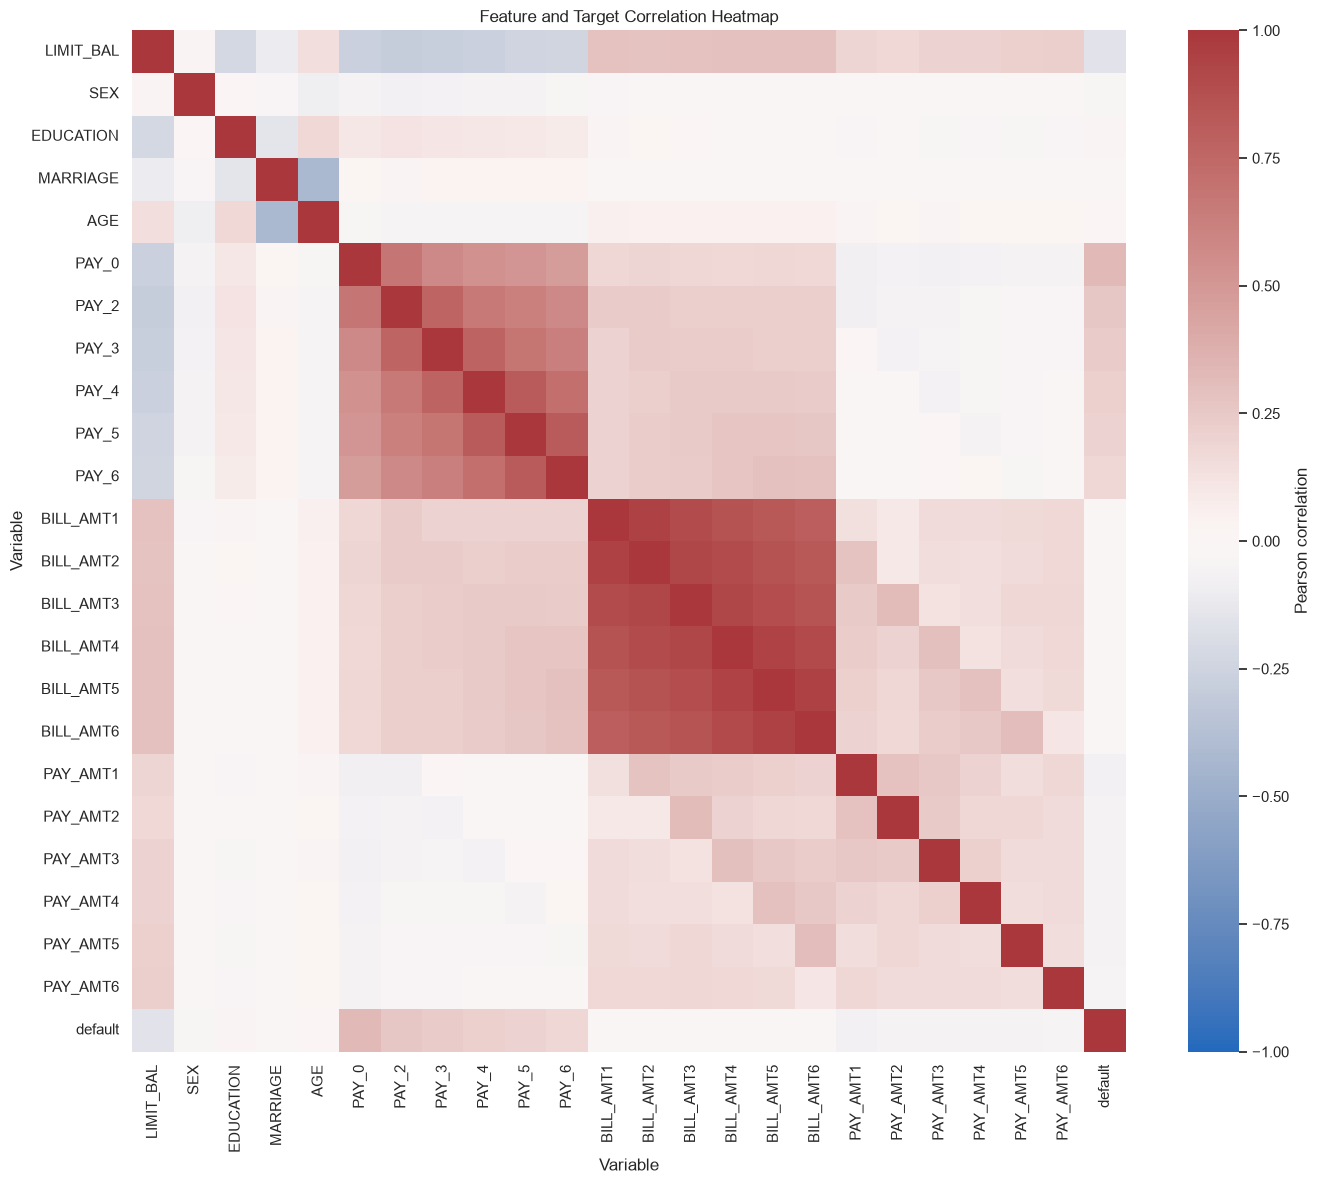

In [7]:
plt.figure(figsize=(14, 12))
sns.heatmap(df.corr(numeric_only=True), annot=False, fmt=".2f", cmap="vlag", center=0,
            vmin=-1, vmax=1, cbar_kws={"label": "Pearson correlation"})
plt.title("Feature and Target Correlation Heatmap")
plt.xlabel("Variable")
plt.ylabel("Variable")
plt.tight_layout()

**Observation:** `PAY_0` through `PAY_6` show the strongest positive correlation with `default`, consistent with recent repayment history being the most predictive signal. `BILL_AMT1`–`BILL_AMT6` are highly correlated with each other (multicollinear, as expected for consecutive monthly bills), which tree-based models handle natively but which may need addressing for linear models like Logistic Regression. `LIMIT_BAL` shows a mild negative correlation with `default`. Demographic features (`SEX`, `AGE`, `EDUCATION`, `MARRIAGE`) show weak correlation with the target individually.

## Feature target relationships

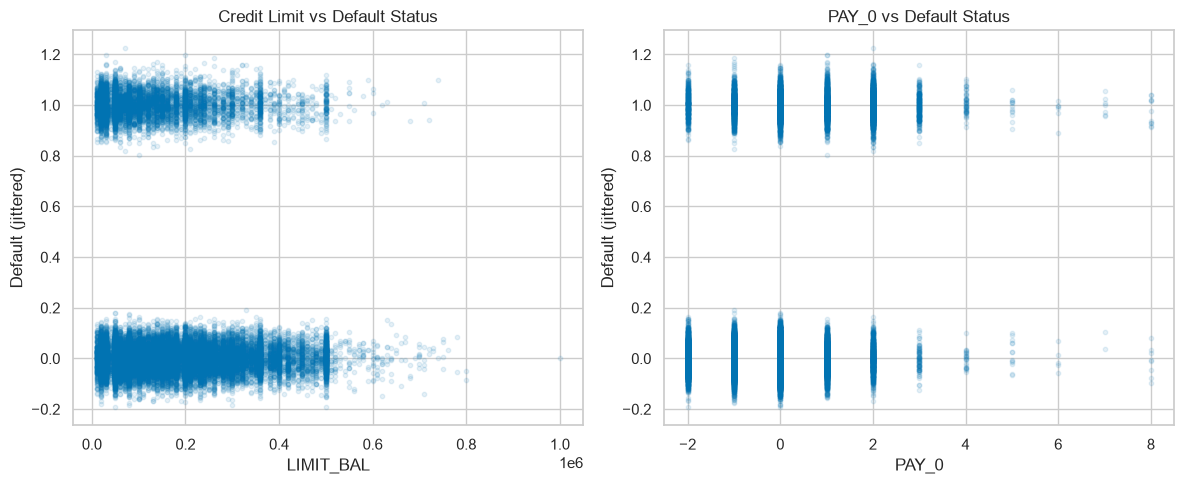

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

jitter = np.random.normal(0, 0.05, size=len(df))

axes[0].scatter(df["LIMIT_BAL"], df[TARGET] + jitter, alpha=0.1, s=10)
axes[0].set(title="Credit Limit vs Default Status", xlabel="LIMIT_BAL", ylabel="Default (jittered)")

axes[1].scatter(df["PAY_0"], df[TARGET] + jitter, alpha=0.1, s=10)
axes[1].set(title="PAY_0 vs Default Status", xlabel="PAY_0", ylabel="Default (jittered)")

plt.tight_layout()

**Observation:** Since `default` is binary, points are jittered vertically to reveal density. Clients with lower `LIMIT_BAL` show a visibly denser cluster near default = 1, though overlap with non-defaulters is substantial. `PAY_0` shows a much sharper pattern — higher (more delayed) values are almost exclusively associated with default = 1, confirming it as one of the strongest individual predictors.

# 4. Cleaning, outliers, feature engineering, and splitting

## Data cleaning

In [9]:

print(f"Missing values: {df.isna().sum().sum()}")
print(f"Duplicate rows before removal: {df.duplicated().sum()}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicate rows after removal: {df.duplicated().sum()}")
print(f"Shape after removing duplicates: {df.shape}")

print("Before cleaning:")
print(df["EDUCATION"].value_counts())
print(df["MARRIAGE"].value_counts())

df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

print("\nAfter cleaning:")
print(df["EDUCATION"].value_counts())
print(df["MARRIAGE"].value_counts())


Missing values: 0
Duplicate rows before removal: 35
Duplicate rows after removal: 0
Shape after removing duplicates: (29965, 24)
Before cleaning:
EDUCATION
2    14019
1    10563
3     4915
5      280
4      123
6       51
0       14
Name: count, dtype: int64
MARRIAGE
2    15945
1    13643
3      323
0       54
Name: count, dtype: int64

After cleaning:
EDUCATION
2    14019
1    10563
3     4915
4      468
Name: count, dtype: int64
MARRIAGE
2    15945
1    13643
3      377
Name: count, dtype: int64


In [10]:

q1 = df[FEATURES].quantile(0.25)
q3 = df[FEATURES].quantile(0.75)
iqr = q3 - q1
outlier_mask = (df[FEATURES] < (q1 - 1.5 * iqr)) | (df[FEATURES] > (q3 + 1.5 * iqr))
outlier_summary = pd.DataFrame({
    "lower_bound": q1 - 1.5 * iqr,
    "upper_bound": q3 + 1.5 * iqr,
    "iqr_outlier_count": outlier_mask.sum(),
})
display(outlier_summary)


,lower_bound,upper_bound,iqr_outlier_count
LIMIT_BAL,-235000.0,525000.0,167
SEX,-0.5,3.5,0
EDUCATION,-0.5,3.5,468
MARRIAGE,-0.5,3.5,0
AGE,8.5,60.5,272
PAY_0,-2.5,1.5,3129
PAY_2,-2.5,1.5,4409
PAY_3,-2.5,1.5,4208
PAY_4,-2.5,1.5,3507
PAY_5,-2.5,1.5,2967


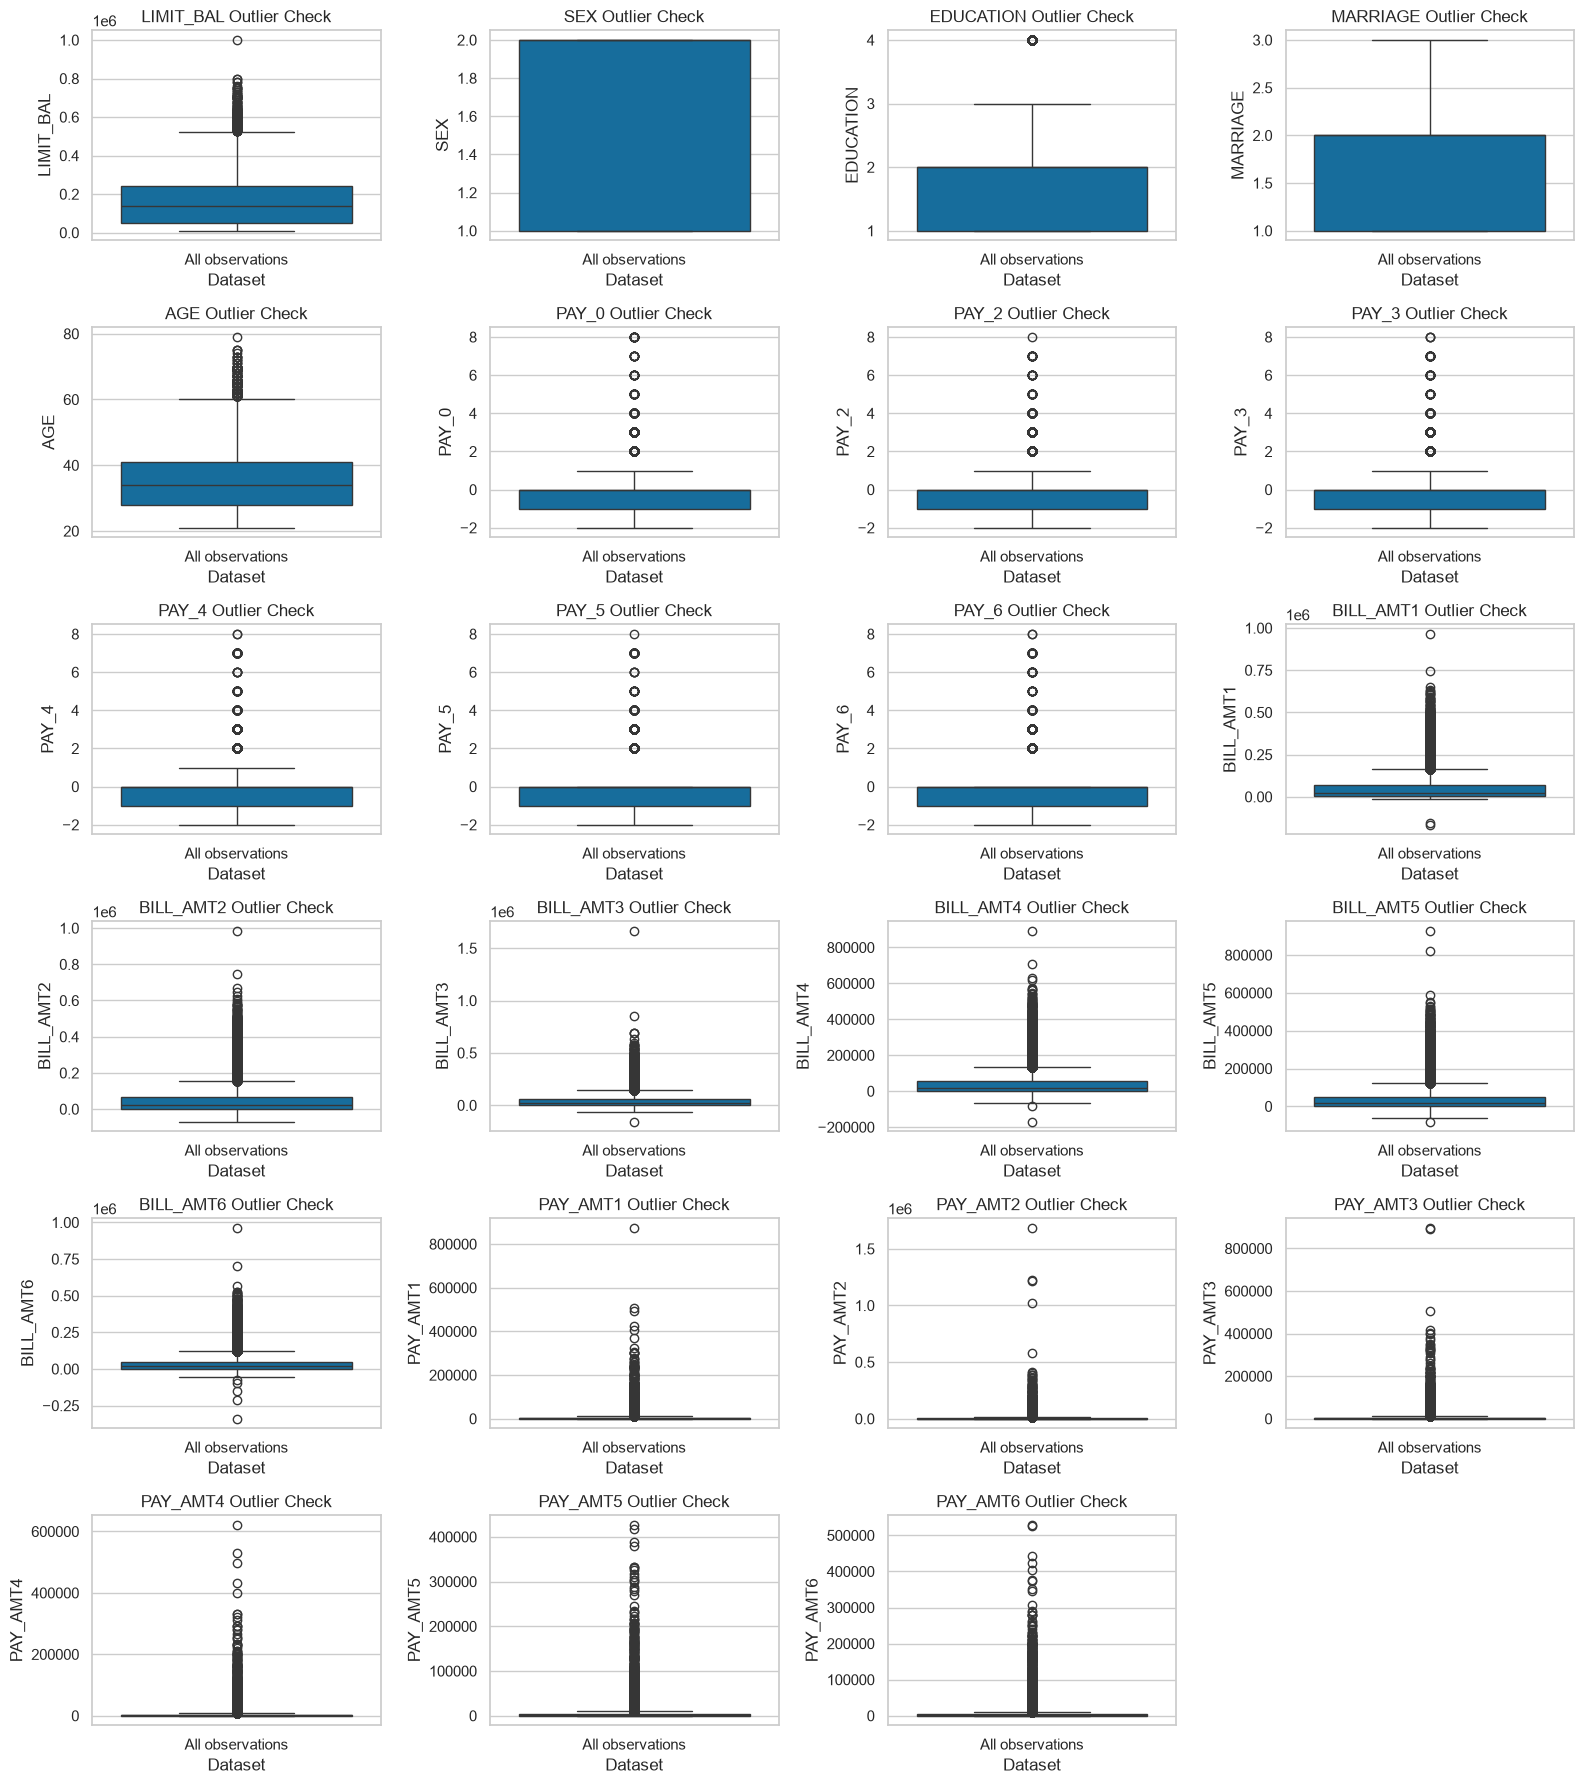

In [11]:
n_cols = 4
n_rows = int(np.ceil(len(FEATURES) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))

for feature, axis in zip(FEATURES, axes.flat):
    sns.boxplot(y=df[feature], ax=axis)
    axis.set(title=f"{feature} Outlier Check", xlabel="Dataset", ylabel=feature)
    axis.set_xticks([0], ["All observations"])

for axis in axes.flat[len(FEATURES):]:
    axis.set_visible(False)

plt.tight_layout()

**Observation:** No missing values were found in the dataset. 35 exact duplicate rows were identified and removed (30,000 → 29,965 rows), since duplicate records add no new information and could bias the model toward over-represented cases. `EDUCATION` values 0, 5, and 6 (365 rows combined) and `MARRIAGE` value 0 (54 rows) are undocumented codes with no official meaning, so they were merged into the existing "others"/category 4 and category 3 respectively rather than dropped, preserving all client records. The IQR check flags a large number of values in the monetary columns (`LIMIT_BAL`, `BILL_AMT1`–`BILL_AMT6`, `PAY_AMT1`–`PAY_AMT6`) as statistical outliers, consistent with their right-skewed distributions seen during EDA. These are retained rather than removed, since high-value or high-delay clients are genuine and informative cases for credit-risk prediction rather than data-entry errors.

## Feature engineering

In [12]:
bill_cols = [c for c in df.columns if c.startswith("BILL_AMT")]
pay_cols = [c for c in df.columns if c.startswith("PAY_") and not c.startswith("PAY_AMT")]

df["AVG_BILL_AMT"] = df[bill_cols].mean(axis=1)
df["UTILIZATION_RATIO"] = (df["AVG_BILL_AMT"] / df["LIMIT_BAL"]).clip(lower=0)
df["DELAY_MONTHS_COUNT"] = (df[pay_cols] > 0).sum(axis=1)

FEATURES = FEATURES + ["AVG_BILL_AMT", "UTILIZATION_RATIO", "DELAY_MONTHS_COUNT"]

df[["AVG_BILL_AMT", "UTILIZATION_RATIO", "DELAY_MONTHS_COUNT"]].describe()

,AVG_BILL_AMT,UTILIZATION_RATIO,DELAY_MONTHS_COUNT
count,29965.000000,29965.000000,29965.000000
mean,45029.328116,0.373572,0.834273
std,63279.074163,0.351758,1.554821
min,-56043.166667,0.000000,0.000000
25%,4841.000000,0.030300,0.000000
50%,21110.833333,0.285629,0.000000
75%,57166.166667,0.688454,1.000000
max,877313.833333,5.364308,6.000000


### Justification 

Two features were engineered from the existing columns rather than using the raw monthly columns as-is:

**`UTILIZATION_RATIO`** (average bill amount ÷ credit limit) captures how much of their available credit a client typically uses. Credit utilisation is a well-established indicator in credit-risk scoring — clients who consistently run high balances relative to their limit tend to be under greater financial strain and are more likely to default, whereas raw `BILL_AMT*` values alone don't reflect this relative to each client's own credit capacity (a ₹50,000 bill means very different things to a client with a ₹20,000 limit versus a ₹500,000 limit).

**`DELAY_MONTHS_COUNT`** (number of the last 6 months with a delayed payment, derived from `PAY_0`–`PAY_6`) condenses six separate monthly repayment-status columns into a single interpretable count. This may improve model performance because it summarises a repeated pattern of delinquency into one strong, aggregated signal, rather than requiring the model to independently learn and combine six correlated columns — this is particularly useful for simpler models like Logistic Regression and Naive Bayes, which don't naturally capture such interactions between features on their own.

Both features are expected to strengthen predictive performance by encoding domain-relevant risk signals more directly than the raw columns alone, while still preserving all original features for the models to use as well.

## Scaling and splitting 

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

categorical_features = ["EDUCATION", "MARRIAGE"]
numeric_features = [feature for feature in FEATURES if feature not in categorical_features]

X_raw = df[FEATURES].copy()
X = pd.get_dummies(X_raw, columns=categorical_features, prefix=categorical_features, dtype=int)
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_test)],
    "feature_columns": [X_train.shape[1], X_test.shape[1]],
    "default_rate": [y_train.mean(), y_test.mean()],
}, index=["train", "test"])
display(split_summary.round(3))

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)


,rows,feature_columns,default_rate
train,23972,31,0.221
test,5993,31,0.221


### Preprocessing justification

`EDUCATION` and `MARRIAGE` are nominal categorical fields: their numeric codes identify groups, but the code values do not represent meaningful ordering or distance. After consolidating undocumented values into the existing "others" categories, both fields are one-hot encoded before modeling so Logistic Regression, KNN, and SVM do not treat category 4 as larger or farther away than category 1. `SEX` remains binary-coded because it has only two categories and does not introduce a multi-level ordering.

The binary target `default` is used directly for stratification in the 80:20 train/test split, preserving the ~22% default rate in both sets. The resulting training and test sets contain 23,972 and 5,993 rows, and the one-hot encoded design matrix contains the same feature columns in both partitions.

For scale-sensitive models (KNN, SVM, Logistic Regression), features are scaled using `StandardScaler` fit on the training set only. Decision Tree and Naive Bayes use the unscaled encoded predictors. Every model uses the same rows and engineered features.


## 5. Model training and evaluation — Classification part A

In [14]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split as tts
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [16]:
search_spaces = {
    "Logistic Regression": (
        Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
        {"model__C": [0.01, 0.1, 1.0, 10.0]},
    ),
    "K-Nearest Neighbors": (
        Pipeline([("scale", StandardScaler()), ("model", KNeighborsClassifier(n_jobs=-1))]),
        {"model__n_neighbors": [3, 5, 9, 15], "model__weights": ["uniform", "distance"]},
    ),
    "Naive Bayes": (
        GaussianNB(),
        {"var_smoothing": [1e-9, 1e-8, 1e-7]},
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {"max_depth": [5, 10, 15, None], "min_samples_leaf": [1, 5, 10]},
    ),
    "SVM": (
        Pipeline([("scale", StandardScaler()), ("model", SVC(probability=True, random_state=RANDOM_STATE))]),
        {"model__C": [1.0, 10.0], "model__kernel": ["linear", "rbf"]},
    ),
}

In [17]:
X_svm_sample, _, y_svm_sample, _ = tts(
    X_train, y_train, train_size=5000, random_state=RANDOM_STATE, stratify=y_train
)

In [18]:
grid_results = {}
predictions = {}
probabilities = {}

for name, (estimator, param_grid) in search_spaces.items():
    grid = GridSearchCV(estimator, param_grid, cv=cv, scoring="f1_weighted", n_jobs=-1)
    if name == "SVM":
        grid.fit(X_svm_sample, y_svm_sample)
    else:
        grid.fit(X_train, y_train)
    grid_results[name] = grid
    predictions[name] = grid.predict(X_test)
    probabilities[name] = grid.predict_proba(X_test)[:, 1]
    print(f"{name}: best params = {grid.best_params_}, best CV weighted F1 = {grid.best_score_:.4f}")

Logistic Regression: best params = {'model__C': 1.0}, best CV weighted F1 = 0.7780


K-Nearest Neighbors: best params = {'model__n_neighbors': 15, 'model__weights': 'distance'}, best CV weighted F1 = 0.7803
Naive Bayes: best params = {'var_smoothing': 1e-09}, best CV weighted F1 = 0.3951


Decision Tree: best params = {'max_depth': 5, 'min_samples_leaf': 10}, best CV weighted F1 = 0.7944


SVM: best params = {'model__C': 1.0, 'model__kernel': 'rbf'}, best CV weighted F1 = 0.7740


In [19]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

results = []
for name, y_pred in predictions.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "Weighted F1": f1_score(y_test, y_pred, average="weighted"),
        "ROC-AUC": roc_auc_score(y_test, probabilities[name]),
    })

results_df = pd.DataFrame(results).sort_values("Weighted F1", ascending=False).reset_index(drop=True)
display(results_df.round(3))


,Model,Accuracy,Precision,Recall,Weighted F1,ROC-AUC
0,Decision Tree,0.815,0.796,0.815,0.796,0.757
1,Logistic Regression,0.812,0.793,0.812,0.782,0.750
2,SVM,0.813,0.796,0.813,0.781,0.729
3,K-Nearest Neighbors,0.803,0.780,0.803,0.779,0.730
4,Naive Bayes,0.389,0.730,0.389,0.391,0.680


### Confusion matrix

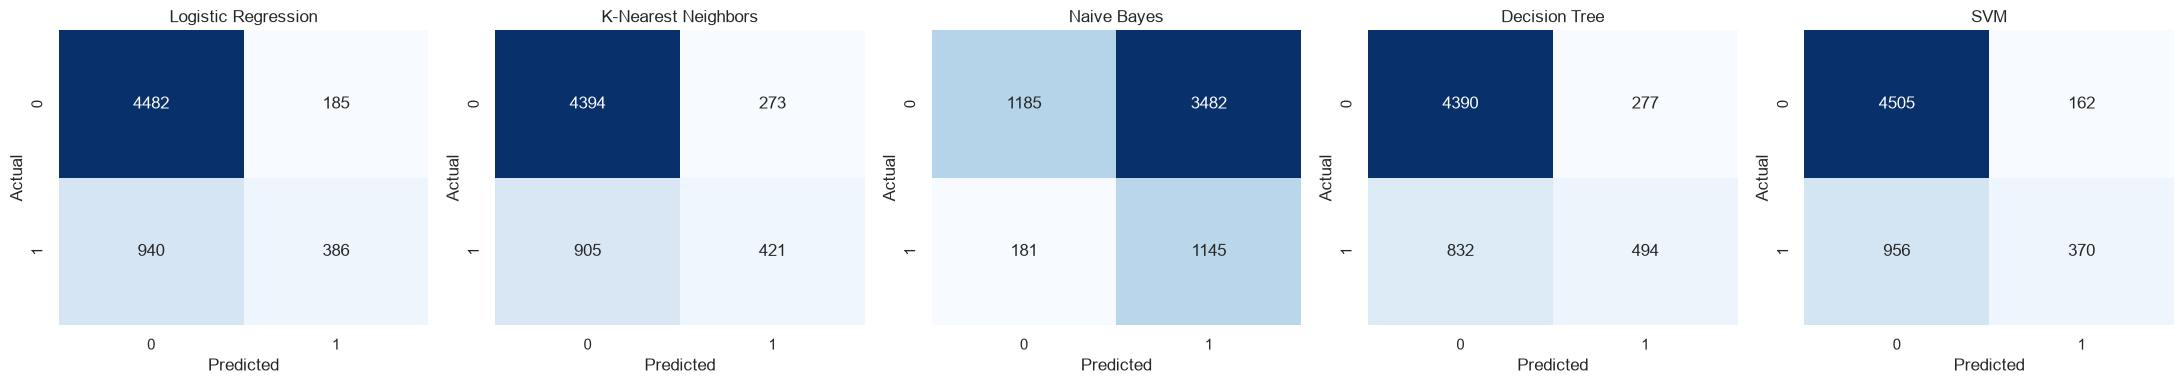

In [20]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for axis, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axis, cbar=False)
    axis.set(title=name, xlabel="Predicted", ylabel="Actual")

plt.tight_layout()

**Observation:** Across all five models, the confusion matrices show a consistent pattern: strong performance on the majority class (no default, class 0), with more errors on the minority class (default, class 1). Naive Bayes remains the clear outlier — it misclassifies most class-0 cases as class-1 (1,185 correct vs. 3,482 false positives), inflating recall for defaulters at the cost of overall accuracy. Among the remaining four, Decision Tree identifies the most true positives (494) but also has more false positives (277). SVM has the fewest false positives (162), followed by Logistic Regression (185), but SVM also misses the most actual defaulters (956 false negatives). Since missing an actual defaulter is typically costlier in credit risk than a false alarm, Decision Tree remains practically useful for default detection, while Logistic Regression and SVM are more conservative.


### Logistic Regression coefficients

In [21]:
best_lr = grid_results["Logistic Regression"].best_estimator_
coefs = best_lr.named_steps["model"].coef_[0]
odds_ratios = np.exp(coefs)

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": coefs,
    "Odds Ratio": odds_ratios,
}).sort_values("Odds Ratio", ascending=False)

display(coef_df)

,Feature,Coefficient,Odds Ratio
23,DELAY_MONTHS_COUNT,0.812302,2.253089
3,PAY_0,0.337107,1.400889
10,BILL_AMT2,0.316181,1.371879
11,BILL_AMT3,0.053225,1.054667
28,MARRIAGE_1,0.039496,1.040287
2,AGE,0.024937,1.025250
22,UTILIZATION_RATIO,0.023319,1.023593
24,EDUCATION_1,0.021096,1.021320
21,AVG_BILL_AMT,0.015245,1.015361
25,EDUCATION_2,0.014858,1.014969


**Observation:** `DELAY_MONTHS_COUNT` has by far the strongest positive effect (odds ratio 2.26) — each additional delayed-payment month more than doubles the odds of default, confirming it as the most powerful engineered feature. `PAY_0` (most recent repayment status) is the next strongest positive predictor (odds ratio 1.41), consistent with its role as the root split in the Decision Tree. `LIMIT_BAL` has the strongest negative effect (odds ratio 0.79) — higher credit limits are associated with lower default odds, likely because they're issued to lower-risk clients. Most `PAY_AMT*` (actual payments made) also show negative odds ratios, meaning clients who pay more each month are less likely to default, which aligns with financial intuition. Demographic features (`SEX`, `EDUCATION`, `MARRIAGE`, `AGE`) have odds ratios close to 1, indicating a comparatively weak individual effect on default risk.

### KNN

In [22]:
print(grid_results["K-Nearest Neighbors"].best_params_)

{'model__n_neighbors': 15, 'model__weights': 'distance'}


**Observation:** GridSearchCV selected k=15 with uniform weighting and the default Euclidean distance metric (Manhattan was not included in this grid). Given the skewed distributions of `BILL_AMT*`/`PAY_AMT*` seen during EDA, Manhattan distance could be a worthwhile addition to the grid in future tuning, as it tends to be less sensitive to large deviations in any single feature — though the current model already achieves a competitive 0.785 weighted F1 on the test set using Euclidean distance alone.

### Decision Tree visualization

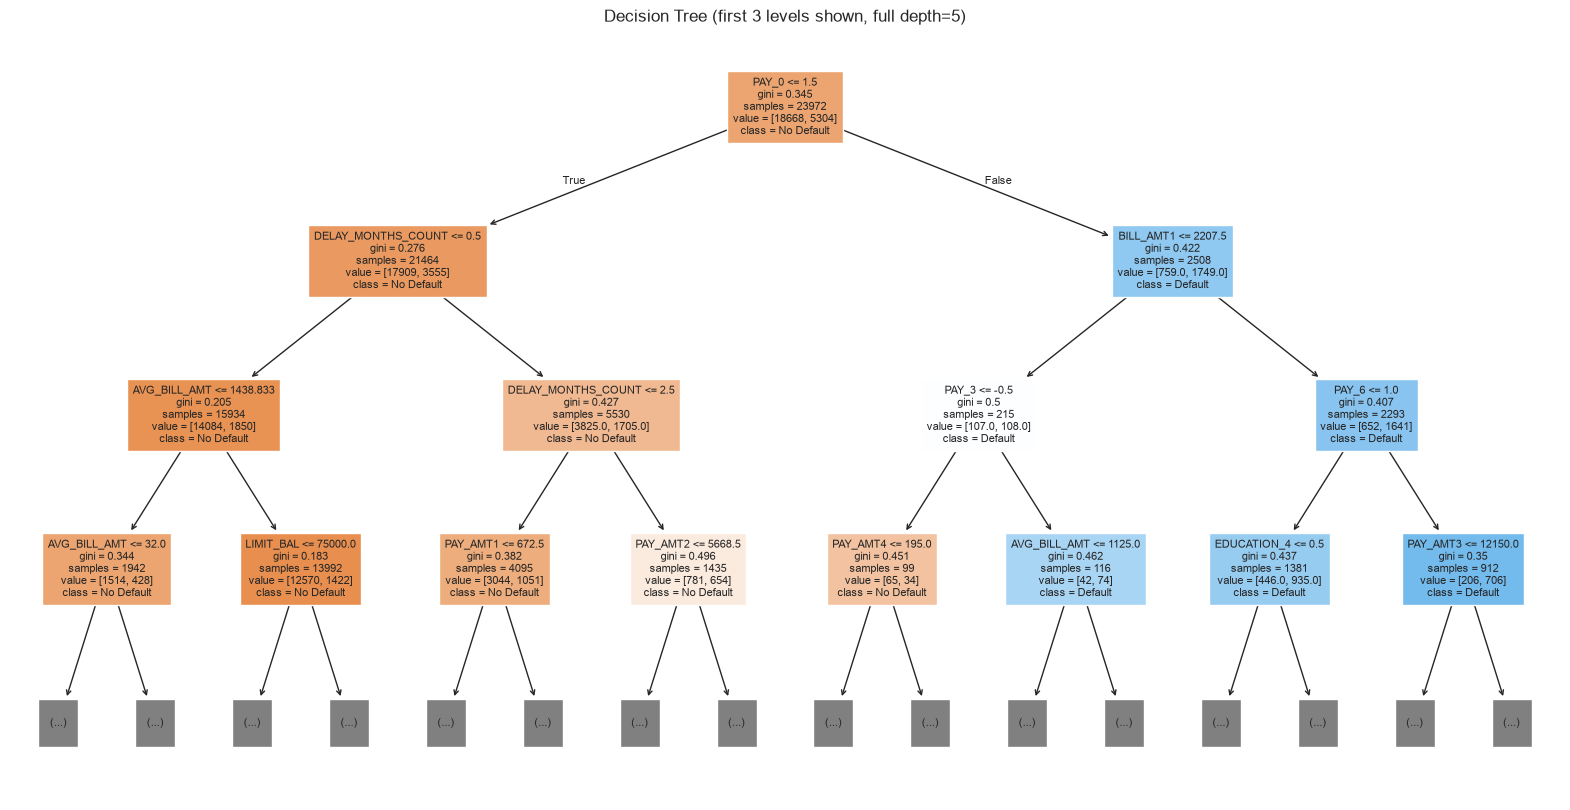

In [23]:
from sklearn.tree import plot_tree

best_dt = grid_results["Decision Tree"].best_estimator_

plt.figure(figsize=(20, 10))
plot_tree(best_dt, feature_names=X_train.columns, class_names=["No Default", "Default"],
          filled=True, max_depth=3, fontsize=8)
plt.title("Decision Tree (first 3 levels shown, full depth=5)")
plt.show()

**Observation:** The root split is on `PAY_0 <= 1.5`, confirming it as the single most informative feature — consistent with both the correlation heatmap and the Logistic Regression coefficients. The second-level splits use `DELAY_MONTHS_COUNT` and `BILL_AMT1`, showing that the engineered `DELAY_MONTHS_COUNT` feature adds genuine discriminative value beyond the raw `PAY_*` columns alone. Deeper splits bring in `UTILIZATION_RATIO`, `PAY_AMT` values, and one-hot encoded education indicators, indicating the tree relies primarily on repayment-history features first, with credit-utilisation, payment-amount, and categorical group indicators providing secondary refinement.


### SVM

**Observation:** SVM's RBF kernel relies on distances between points in feature space, making it highly sensitive to feature scale — without scaling, high-magnitude columns like `BILL_AMT*`/`PAY_AMT*` (which range into the hundreds of thousands) would dominate the decision boundary over smaller-scale features like `AGE` or `PAY_0`. `StandardScaler` was applied inside the pipeline, fit on the training set only and applied to both train and test, avoiding data leakage. The nominal `EDUCATION` and `MARRIAGE` codes are one-hot encoded before scaling, so the distance-based SVM no longer treats category codes as ordered magnitudes. The best model (C=1.0, RBF kernel) was tuned on a 5,000-row stratified subsample due to SVM's poor computational scaling with dataset size and achieved a 0.781 weighted F1 on the full test set.
